# Funcions generals

In [1]:
def grafica_A_i_L(r_aprox, func, l, n_parts):

    h = 2*pi/n_parts
    t_nodes = [i*h for i in range(n_parts+1)]

    r = var('r')
    ddxfunc = diff(func,r).subs(r=r_aprox)

    # A(t_i)
    A_vals = []
    for i in range(n_parts+1):
        A_vals.append(numerical_integral(ddxfunc, 0, t_nodes[i])[0])

    # función A(t)
    A = lambda x: numerical_integral(ddxfunc, 0, x)[0]

    # gráfica numérica de A(t)
    punts_A = []
    n_mostres = 1000
    for j in range(n_mostres+1):
        xj = RDF(2*pi*j/n_mostres)
        punts_A.append((xj, A(xj)))

    graf_A = line(punts_A, color='blue', thickness=0.1)

    # construcción de L(t)
    trozos = []

    for i in range(n_parts):

        pendiente = (A_vals[i+1]-A_vals[i])/h

        Li = (
            A_vals[i]
            - l
            + pendiente*(t - t_nodes[i])
        )

        trozos.append(
            plot(
                Li,
                (t, t_nodes[i], t_nodes[i+1]),
                color='red',
                thickness=0.1
            )
        )

    graf_L = sum(trozos)

    show(graf_A + graf_L, figsize=8)

In [2]:
def calcula_fita_M(r_aprox, func, l, n_parts):
    h = RR(2*pi/n_parts)
    t_nodes = [RR(i*h) for i in range(n_parts+1)]
    
    r = var('r')
    ddxfunc = diff(func,r).subs(r=r_aprox)
    
    # Calculem tots els termes que van per segments
    A_vals = []
    for i in range(n_parts + 1):
        A_vals.append(RR(numerical_integral(ddxfunc, 0, t_nodes[i])[0]))
    
    lambda_val = RR(exp(A_vals[-1]))
    
    alpha_vals = []
    beta_vals = []
    J_vals = []
    for i in range(n_parts):
        alpha_i = RR(-2*(A_vals[i+1]-A_vals[i])/h)
        alpha_vals.append(alpha_i)
        
        beta_i = RR(-alpha_i*t_nodes[i] - 2*(A_vals[i] - l))
        beta_vals.append(beta_i)
        
        #J_i
        if (abs(alpha_i) < 1e-10): #tractem com si fos 0
            J_i = RR(exp(beta_i)*h)
        else:
            J_i = RR(exp(beta_i)/alpha_i * (exp(alpha_i*t_nodes[i+1]) - exp(alpha_i*t_nodes[i])))
        
        J_vals.append(J_i)
        
    # Calculem el màxim.
    # Per simplificar els càlculs, aprofitem que psi és exponencial i només calcularem el màxim als extrems
    # de l'interval, obviant l'altra exponencial e^A(t)
    producte_max_global = RR(0)

    for i in range(n_parts):
        suma_1 = RR(sum(J_vals[:i]))
        suma_2 = RR(sum(J_vals[i:]))

        if (abs(alpha_vals[i]) < 1e-10):
            psi_0 = suma_1 + lambda_val^2*suma_2
            psi_1 = suma_1 + lambda_val^2*suma_2 + (1 - lambda_val^2)*exp(beta_vals[i])*(t_nodes[i+1]-t_nodes[i])
        else:
            psi_0 = suma_1 + lambda_val^2*suma_2
            psi_1 = suma_1 + lambda_val^2*suma_2 + (1 - lambda_val^2)*(exp(beta_vals[i])/alpha_vals[i])*(exp(alpha_vals[i]*t_nodes[i+1]) - exp(alpha_vals[i]*t_nodes[i]))

        producte_0 = exp(A_vals[i]) * sqrt(psi_0)
        producte_1 = exp(A_vals[i+1]) * sqrt(psi_1)

        max_tram = max(producte_0, producte_1)

        if max_tram > producte_max_global:
            producte_max_global = max_tram

    M_fita = (sqrt(2*pi) / abs(1 - lambda_val)) * producte_max_global
    return RR(M_fita)

In [3]:
def calcula_accuracy(F_aprox):
    return sqrt((1/(2*pi))*numerical_integral(F_aprox^2, 0, 2*pi)[0])

# Definició de l'equació diferencial

In [4]:
var('t')
r = function('r')(t)

a = -1
b = 0
c = 0
d = 4
e = 2
f = 2

def func(x):
    return a*x + (b*cos(t) + c*sin(t))*x^2 +(d*(cos(t))^2 + e*cos(t)*sin(t) + f*(sin(t)^2))*x^3

# fr = a*r + (b*cos(t) + c*sin(t))*r^2 +(d*(cos(t))^2 + e*cos(t)*sin(t) + f*(sin(t)^2))*r^3
fr = func(r)
show(fr)

show(fr.trig_reduce())

2*(2*cos(t)^2 + cos(t)*sin(t) + sin(t)^2)*r(t)^3 - r(t)

cos(2*t)*r(t)^3 + r(t)^3*sin(2*t) + 3*r(t)^3 - r(t)

In [5]:
edo = diff(r, t) == fr.trig_reduce()

sol = desolve(edo, r, ivar=t)

show(sol.simplify_full().trig_reduce())

1/sqrt(_C*e^(2*t) + cos(2*t) + 3)

In [6]:
sol_periodica = sol.simplify_full().trig_reduce().subs(_C=0)
show(sol_periodica)

1/sqrt(cos(2*t) + 3)

In [7]:
drfunc = diff(func(x),x)
print(integral(drfunc.subs(x=sol_periodica), t, 0, 2*pi))

4*pi


Notem que la funció és parella, només cal considerar els termes de cosinus de la sèrie de Fourier. A més la sèrie és $\pi$-periòdica, pel que només cal considerar els termes de índex parell, la resta s'anul·laran. Si no s'anulessin, la sèrie de Fourier no tindria caràcter $\pi$-periòdic, sinò $2\pi$.

In [8]:
# Fourier explícita
M=5

A0 = numerical_integral(sol_periodica(t), 0, 2*pi)[0]/(2*pi)

A = [A0]

for n in range(1, M+1):
    An = numerical_integral(sol_periodica(t)*cos(2*n*t), 0, 2*pi)[0]/pi
    A.append(An)

for i in range(0, M+1):
    print(f"A_{2*i} =", A[i].n())

A_0 = 0.590170299508048
A_2 = -0.101635396639338
A_4 = 0.0130947202186514
A_6 = -0.00187341906592405
A_8 = 0.000281355039999998
A_10 = -0.0000434564953927155


# MBH

Partim de la coneixença que la solució és parella i $\pi$-periòdica i que la freqüencia és 1.

In [9]:
# Funció per generar una sèrie de Fourier truncada de grau N en termes de sinus i cosinus.
var('t w')
def fourierTruncadaParticular(grau):
    A_0 = var('A_0')
    A_coeficients = [A_0]
    
    serieDeFourier = A_0
    
    for n in range(1, grau+1):
        if (n % 2 == 0):
            A_n = var(f'A_{n}')
        
            A_coeficients.append(A_n)
            serieDeFourier += A_n*cos(n*t)
    
    return serieDeFourier, A_coeficients

## Ordre 0

In [10]:
r_0 = fourierTruncadaParticular(0)[0]
show(r_0)

F = diff(r_0, t) - func(r_0)
F = F.trig_reduce()
show(F)

A_0

-A_0^3*cos(2*t) - A_0^3*sin(2*t) - 3*A_0^3 + A_0

In [11]:
# Anul·lem l'harmònic de grau 0
alpha_0 = integral(F, t, 0, 2*pi)
show(alpha_0)
solve(alpha_0 == 0, A_0)

-6*pi*A_0^3 + 2*pi*A_0

[A_0 == -1/3*sqrt(3), A_0 == 1/3*sqrt(3), A_0 == 0]

La única solució positiva és 1/3*sqrt(3)

In [12]:
(1/3*sqrt(3)).n()

0.577350269189626

In [13]:
r_aprox_0 = 1/3*sqrt(3)
F_aprox = diff(r_aprox_0, t) - func(r_aprox_0)
F_aprox = F_aprox.trig_reduce()
show(F_aprox)

-1/9*sqrt(3)*cos(2*t) - 1/9*sqrt(3)*sin(2*t)

In [14]:
accuracy = calcula_accuracy(F_aprox)
print(accuracy.n())

0.192450089729875


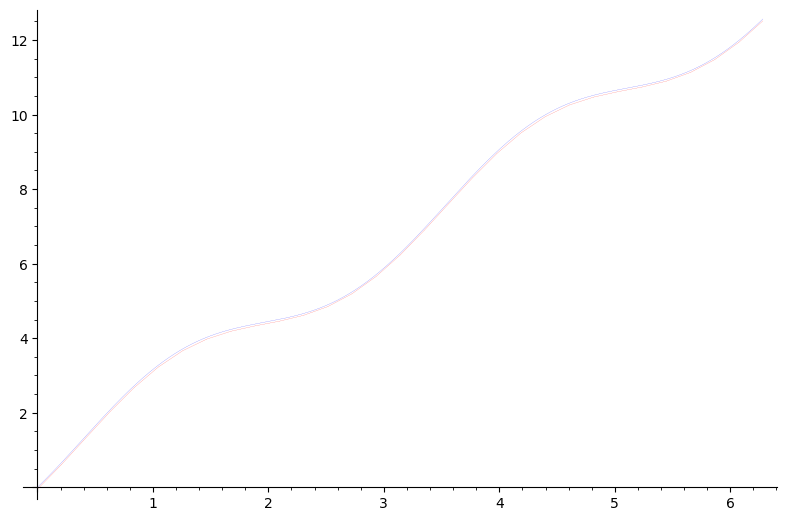

In [16]:
grafica_A_i_L(r_aprox_0, func(r), 1/20, 30)

In [17]:
var('r')
ctt_deformacio = calcula_fita_M(r_aprox_0, func(r), 1/20, 30)
print(ctt_deformacio)

1.98042127016476


Donem l'interval

In [18]:
MS2 = 2*ctt_deformacio*accuracy
MS2.n()

0.762264502292321

In [19]:
I_esq = r_aprox_0-MS2
I_dret = r_aprox_0+MS2

print(I_esq.n())
print(I_dret.n())

-0.184914233102696
1.33961477148195


Calculem K

In [20]:
ddf = diff(func(r), r, 2)
show(ddf.trig_reduce())

6*r*cos(2*t) + 6*r*sin(2*t) + 18*r

A mà veiem que podem calcular el màxim descomponent com
$$6 (\max(\cos(2t)+\sin(2t)+3))(\max(r))$$

In [21]:
K = 6*(3+sqrt(2))*I_dret
print(K.n())

35.4800741557857


In [22]:
(2*ctt_deformacio^2*K*accuracy).n()

53.5608914502658

## Ordre 2

In [23]:
r_2 = fourierTruncadaParticular(2)[0]

F = diff(r_2, t) - func(r_2)
F = F.trig_reduce()
show(F)

-1/8*A_2^3*cos(8*t) - 3/4*A_0*A_2^2*cos(6*t) - 3/4*A_2^3*cos(6*t) - 3/2*A_0^2*A_2*cos(4*t) - 9/2*A_0*A_2^2*cos(4*t) - 1/2*A_2^3*cos(4*t) - A_0^3*cos(2*t) - 9*A_0^2*A_2*cos(2*t) - 9/4*A_0*A_2^2*cos(2*t) - 9/4*A_2^3*cos(2*t) - 1/8*A_2^3*sin(8*t) - 3/4*A_0*A_2^2*sin(6*t) - 3/2*A_0^2*A_2*sin(4*t) - 1/4*A_2^3*sin(4*t) - A_0^3*sin(2*t) - 3/4*A_0*A_2^2*sin(2*t) - 3*A_0^3 - 3/2*A_0^2*A_2 - 9/2*A_0*A_2^2 - 3/8*A_2^3 + A_2*cos(2*t) - 2*A_2*sin(2*t) + A_0

In [24]:
# Harmònic de grau 0
alpha_0 = (integral(F, t, 0, 2*pi)/(2*pi)).expand()
show(alpha_0)

-3*A_0^3 - 3/2*A_0^2*A_2 - 9/2*A_0*A_2^2 - 3/8*A_2^3 + A_0

In [25]:
# Harmònic de grau 2
alpha_2 = (integral(F*cos(2*t), t, 0, 2*pi)/pi).expand()
show(alpha_2)

-A_0^3 - 9*A_0^2*A_2 - 9/4*A_0*A_2^2 - 9/4*A_2^3 + A_2

In [26]:
R1 = alpha_0.resultant(alpha_2, A_0)
show(R1)
R2 = alpha_0.resultant(alpha_2, A_2)
show(R2)

3110373/512*A_2^9 - 167751/32*A_2^7 + 43227/32*A_2^5 - 441/4*A_2^3 + A_2

-3110373/512*A_0^9 + 790641/256*A_0^7 - 195021/512*A_0^5 + 1917/128*A_0^3 - 9/64*A_0

In [27]:
sols_A_0 = solve(R2==0, A_0)

In [28]:
sols_A_0_reals = []

for s in sols_A_0:
    val = s.rhs().n(digits=200)
    
    if abs(val.imag()) < 1e-100:
        sols_A_0_reals.append(val.real())

sols_A_0_reals

[-0.58995011734479538888432834002860125712066429537099435067623291854838692600208141478837854477714975321752148852902462967626545719526612600801444751142730203376745874302119749761016223178714425989463103,
 0.58995011734479538888432834002860125712066429537099435067623291854838692600208141478837854477714975321752148852902462967626545719526612600801444751142730203376745874302119749761016223178714425989463103,
 -0.30891269927726905004570508287380321899988052175903348563657738844040536047647902338595349777946410541749863187273972355333557711751815369041545516196377061057849804494207625411977351822182406486618464,
 0.30891269927726905004570508287380321899988052175903348563657738844040536047647902338595349777946410541749863187273972355333557711751815369041545516196377061057849804494207625411977351822182406486618464,
 -0.226601132285217098798819640753574302004895753092104137069374563088639325063574773626383979548987553546335219703431788190851570822052814303929755668951722226236283230995536043

In [29]:
sols_A_2 = solve(R1==0, A_2)

In [30]:
sols_A_2_reals = []

for s in sols_A_2:
    val = s.rhs().n(digits=200)
    
    if abs(val.imag()) < 1e-100:
        sols_A_2_reals.append(val.real())

sols_A_2_reals

[-0.68639893350775032053438985861529621919512512981787406247190723962287607973449332589881344686801719134924482437750405553410156078702662044100432871130129065065580945062430339151385720107801781070769868,
 0.68639893350775032053438985861529621919512512981787406247190723962287607973449332589881344686801719134924482437750405553410156078702662044100432871130129065065580945062430339151385720107801781070769868,
 -0.49102046371167035680049702578171803851626453131021213267010718418733336357624046028820821499050966162640655050209586430214308729348339393141325295008241373612691681869541687070045917164889306603043046,
 0.49102046371167035680049702578171803851626453131021213267010718418733336357624046028820821499050966162640655050209586430214308729348339393141325295008241373612691681869541687070045917164889306603043046,
 -0.374639641213954588729396851887068832499316742235068977804729674110394240879573620488717945168332375455799252162576113752235085031648967027466602534357540700310074053767436498

Escollim una solució, la que faci més petits els harmònics

In [31]:
error_min = infinity

for a0 in sols_A_0_reals:
    for a2 in sols_A_2_reals:
        #descartem la solucio (0,0)
        if (abs(a0)< 1e-30 and abs(a2)< 1e-30):
            continue
        #descartem solucions que fan que el radi sigui negatiu, -1<= cos(2t) <= 1
        # i.e. 0 < A0 -abs(A2) <= r(t) <= A0 + abs(A2)
        if(a0 - abs(a2) <= 0):
            continue
        
        v0 = alpha_0.subs(A_0=a0, A_2=a2).n()
        v2 = alpha_2.subs(A_0=a0, A_2=a2).n()

        error = abs(v0) + abs(v2)

        if error < error_min:
            error_min = error
            A_0_escollit = a0
            A_2_escollit = a2

                    
                    
print(A_0_escollit)
print(A_2_escollit)
print("alpha_0 =", alpha_0.subs(A_0=A_0_escollit, A_2=A_2_escollit).n())
print("alpha_2 =", alpha_2.subs(A_0=A_0_escollit, A_2=A_2_escollit).n())

0.58995011734479538888432834002860125712066429537099435067623291854838692600208141478837854477714975321752148852902462967626545719526612600801444751142730203376745874302119749761016223178714425989463103
-0.10161055483872297052990833869800215524392203779648769946932138093852939277776959684249117311482378204301762645550304385222263158521840054985098798129421732490799343936413035572641693797949879249669108
alpha_0 = 1.17373687744125e-201
alpha_2 = 1.47992910633897e-201


Un cop tenim la aproximació, podem calcular les constants per tal de comprobar l'existència de la solució periòdica.

In [32]:
r_aprox_2 = A_0_escollit + A_2_escollit*cos(2*t)
F_aprox = diff(r_aprox_2, t) - func(r_aprox_2)
F_aprox = F_aprox.trig_reduce()
show(F_aprox)

0.000131137373603166*cos(8*t) - 0.0037814713887868983*cos(6*t) + 0.026161755870707914*cos(4*t) - (1.3877787807814457e-17)*cos(2*t) + 0.000131137373603166*sin(8*t) - 0.004568295630405895*sin(6*t) + 0.05330925490593695*sin(4*t) - 0.006674097900259995*sin(2*t)

In [33]:
accuracy = calcula_accuracy(F_aprox)
print(accuracy.n())

0.0424621063802742


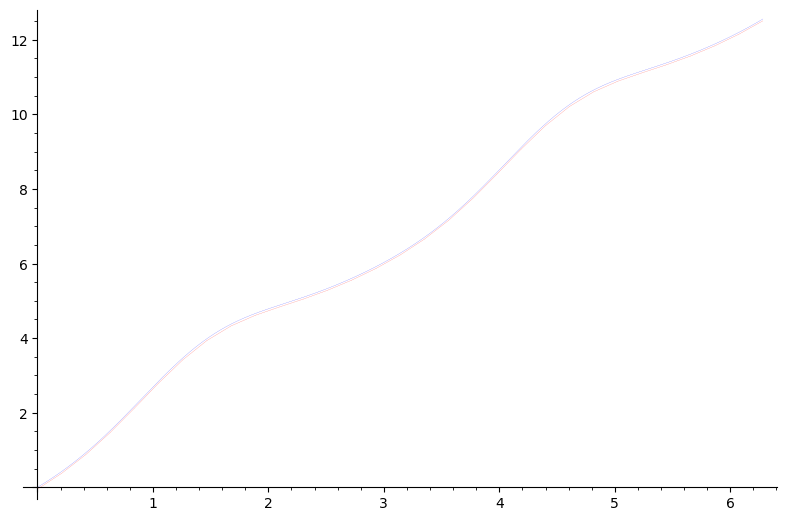

In [34]:
grafica_A_i_L(r_aprox_2, func(r), 1/20, 30)

In [35]:
var('r')
ctt_deformacio = calcula_fita_M(r_aprox_2, func(r), 1/20, 30)
print(ctt_deformacio)

1.73422185258915


Donem l'interval

In [36]:
MS2 = 2*ctt_deformacio*accuracy
MS2.n()

0.147277425583273

In [37]:
# per la naturalesa de l'aproximacio i el signe dels coeficients
r_aprox_min = r_aprox_2.subs(t=0)
r_aprox_max = r_aprox_2.subs(t=pi/2)

print(r_aprox_min)
print(r_aprox_max)

0.48833956250607241835442000133059910187674225757450665120691153760985753322431181794588737166232597117450386207352158582404282561004772545816345953013308470885946530365706714188374529380764546739793995
0.69156067218351835941423667872660341236458633316748205014555429948691631877985101163086971789197353526053911498452767352848808878048452655786543549272151935867545218238532785333657916976664305239132212


In [38]:
I_esq = r_aprox_min-MS2
I_dret = r_aprox_max+MS2

print(I_esq.n())
print(I_dret.n())

0.341062136922799
0.838838097766792


Calculem K

In [39]:
ddf = diff(func(r), r, 2)
show(ddf.trig_reduce())

6*r*cos(2*t) + 6*r*sin(2*t) + 18*r

A mà veiem que podem calcular el màxim descomponent com
$$6 (\max(\cos(2t)+\sin(2t)+3))(\max(r))$$

In [40]:
K = 6*(3+sqrt(2))*I_dret
print(K.n())

22.2168630467845


In [41]:
(2*ctt_deformacio^2*K*accuracy).n()

5.67444742238838

## Ordre 4

In [42]:
r_4, Variables = fourierTruncadaParticular(4)

F = diff(r_4, t) - func(r_4)
F = F.trig_reduce()
show(F)

-1/8*A_4^3*cos(14*t) - 3/8*A_2*A_4^2*cos(12*t) - 3/4*A_4^3*cos(12*t) - 3/8*A_2^2*A_4*cos(10*t) - 3/4*A_0*A_4^2*cos(10*t) - 9/4*A_2*A_4^2*cos(10*t) - 1/8*A_4^3*cos(10*t) - 1/8*A_2^3*cos(8*t) - 3/2*A_0*A_2*A_4*cos(8*t) - 9/4*A_2^2*A_4*cos(8*t) - 9/2*A_0*A_4^2*cos(8*t) - 3/4*A_2*A_4^2*cos(8*t) - 3/4*A_0*A_2^2*cos(6*t) - 3/4*A_2^3*cos(6*t) - 3/2*A_0^2*A_4*cos(6*t) - 9*A_0*A_2*A_4*cos(6*t) - 9/8*A_2^2*A_4*cos(6*t) - 3/4*A_0*A_4^2*cos(6*t) - 9/4*A_2*A_4^2*cos(6*t) - 3/8*A_4^3*cos(6*t) - 3/2*A_0^2*A_2*cos(4*t) - 9/2*A_0*A_2^2*cos(4*t) - 1/2*A_2^3*cos(4*t) - 9*A_0^2*A_4*cos(4*t) - 3*A_0*A_2*A_4*cos(4*t) - 9/2*A_2^2*A_4*cos(4*t) - 9/8*A_2*A_4^2*cos(4*t) - 9/4*A_4^3*cos(4*t) - A_0^3*cos(2*t) - 9*A_0^2*A_2*cos(2*t) - 9/4*A_0*A_2^2*cos(2*t) - 9/4*A_2^3*cos(2*t) - 3/2*A_0^2*A_4*cos(2*t) - 9*A_0*A_2*A_4*cos(2*t) - 3/2*A_2^2*A_4*cos(2*t) - 3/2*A_0*A_4^2*cos(2*t) - 9/2*A_2*A_4^2*cos(2*t) - 3/8*A_4^3*cos(2*t) - 1/8*A_4^3*sin(14*t) - 3/8*A_2*A_4^2*sin(12*t) - 3/8*A_2^2*A_4*sin(10*t) - 3/4*A_0*A_4^2*sin(10*t) + 1/8*A_4^3*sin(10*t) - 1/8*A_2^3*sin(8*t) - 3/2*A_0*A_2*A_4*sin(8*t) - 3/4*A_0*A_2^2*sin(6*t) - 3/2*A_0^2*A_4*sin(6*t) - 3/8*A_2^2*A_4*sin(6*t) + 3/4*A_0*A_4^2*sin(6*t) - 3/8*A_4^3*sin(6*t) - 3/2*A_0^2*A_2*sin(4*t) - 1/4*A_2^3*sin(4*t) - 3/8*A_2*A_4^2*sin(4*t) - A_0^3*sin(2*t) - 3/4*A_0*A_2^2*sin(2*t) + 3/2*A_0^2*A_4*sin(2*t) - 3/2*A_0*A_4^2*sin(2*t) + 3/8*A_4^3*sin(2*t) - 3*A_0^3 - 3/2*A_0^2*A_2 - 9/2*A_0*A_2^2 - 3/8*A_2^3 - 3/2*A_0*A_2*A_4 - 9/4*A_2^2*A_4 - 9/2*A_0*A_4^2 - 3/4*A_2*A_4^2 + A_4*cos(4*t) + A_2*cos(2*t) - 4*A_4*sin(4*t) - 2*A_2*sin(2*t) + A_0

In [43]:
# Harmònic de grau 0
alpha_0 = (integral(F, t, 0, 2*pi)/(2*pi)).expand()
show(alpha_0)

-3*A_0^3 - 3/2*A_0^2*A_2 - 9/2*A_0*A_2^2 - 3/8*A_2^3 - 3/2*A_0*A_2*A_4 - 9/4*A_2^2*A_4 - 9/2*A_0*A_4^2 - 3/4*A_2*A_4^2 + A_0

In [44]:
# Harmònic de grau 2
alpha_2 = (integral(F*cos(2*t), t, 0, 2*pi)/pi).expand()
show(alpha_2)

-A_0^3 - 9*A_0^2*A_2 - 9/4*A_0*A_2^2 - 9/4*A_2^3 - 3/2*A_0^2*A_4 - 9*A_0*A_2*A_4 - 3/2*A_2^2*A_4 - 3/2*A_0*A_4^2 - 9/2*A_2*A_4^2 - 3/8*A_4^3 + A_2

In [45]:
# Harmònic de grau 4
alpha_4 = (integral(F*cos(4*t), t, 0, 2*pi)/pi).expand()
show(alpha_4)

-3/2*A_0^2*A_2 - 9/2*A_0*A_2^2 - 1/2*A_2^3 - 9*A_0^2*A_4 - 3*A_0*A_2*A_4 - 9/2*A_2^2*A_4 - 9/8*A_2*A_4^2 - 9/4*A_4^3 + A_4

In [46]:
sistema_0 = [alpha_0, alpha_2, alpha_4]

In [47]:
# Escollim quin és el millor per pivotar
for i in range(len(Variables)):
    for j in range(len(sistema_0)):
        print(f'Grau de Alpha_{2*j} en {Variables[i]}: {sistema_0[j].degree(Variables[i])}')
    print()

Grau de Alpha_0 en A_0: 3
Grau de Alpha_2 en A_0: 3
Grau de Alpha_4 en A_0: 2

Grau de Alpha_0 en A_2: 3
Grau de Alpha_2 en A_2: 3
Grau de Alpha_4 en A_2: 3

Grau de Alpha_0 en A_4: 2
Grau de Alpha_2 en A_4: 3
Grau de Alpha_4 en A_4: 3



In [48]:
R_1 = alpha_4.resultant(alpha_0, A_0)
show(R_1)
print()
R_2 = alpha_4.resultant(alpha_2, A_0)
show(R_2)

sistema_1 = [R_1, R_2]

-16155/512*A_2^9 - 155331/256*A_2^8*A_4 - 164025/64*A_4^9 - 9/64*(9873*A_4^2 - 209)*A_2^7 - 27/128*(27015*A_4^3 - 2696*A_4)*A_2^6 + 32805/16*A_4^7 - 9/512*(436725*A_4^4 - 61800*A_4^2 + 64)*A_2^5 - 9/256*(418905*A_4^5 - 86904*A_4^3 + 2432*A_4)*A_2^4 - 486*A_4^5 - 27/512*(193455*A_4^6 - 58008*A_4^4 + 4720*A_4^2)*A_2^3 - 9/256*(312255*A_4^7 - 144612*A_4^5 + 16560*A_4^3 - 64*A_4)*A_2^2 + 36*A_4^3 - 9/128*(54675*A_4^8 - 32400*A_4^6 + 5472*A_4^4 - 256*A_4^2)*A_2

-42487/128*A_2^9 - 375867/128*A_2^8*A_4 - 18225/64*A_4^9 + 9/512*(54203*A_4^2 + 9360)*A_2^7 + 3/256*(861003*A_4^3 + 123868*A_4)*A_2^6 + 1215/16*A_4^7 + 27/256*(41585*A_4^4 - 6208*A_4^2 - 32)*A_2^5 - 9/64*(7335*A_4^5 + 42580*A_4^3 + 288*A_4)*A_2^4 - 15/512*(277371*A_4^6 + 8208*A_4^4 + 2816*A_4^2)*A_2^3 - 27/256*(178245*A_4^7 - 57476*A_4^5 - 448*A_4^3)*A_2^2 + A_4^3 - 9/128*(57915*A_4^8 - 12600*A_4^6 - 2336*A_4^4)*A_2

In [49]:
# Escollim quin és el millor per pivotar
Variables_1 = [A_2, A_4]
for i in range(len(Variables_1)):
    for j in range(len(sistema_1)):
        print(f'Grau de Alpha_{2*j} en {Variables_1[i]}: {sistema_1[j].degree(Variables_1[i])}')
    print()

Grau de Alpha_0 en A_2: 9
Grau de Alpha_2 en A_2: 9

Grau de Alpha_0 en A_4: 9
Grau de Alpha_2 en A_4: 9



In [50]:
R2_1 = R_1.resultant(R_2, A_2)

In [51]:
P = R2_1.polynomial(AA)

solucions_reals_A4 = P.roots(AA, multiplicities=False)

for s in solucions_reals_A4:
    print(s.n())

-0.676508290882599
-0.676499631793047
-0.556496612333603
-0.532987144340651
-0.436528054158500
-0.429307317423425
-0.419437259336145
-0.409709691894803
-0.405970715207186
-0.346089371242943
-0.316061015370984
-0.280200527956727
-0.274355776211095
-0.251636108363049
-0.243583315301812
-0.241827060376207
-0.221053260944573
-0.205451404914285
-0.180313502860771
-0.112916615613505
-0.0795147757320595
-0.0130966364392397
-0.0130946610806495
-0.0130703528077145
-0.00203959044267026
0.000000000000000
0.00203959044267026
0.0130703528077145
0.0130946610806495
0.0130966364392397
0.0795147757320595
0.112916615613505
0.180313502860771
0.205451404914285
0.221053260944573
0.241827060376207
0.243583315301812
0.251636108363049
0.274355776211095
0.280200527956727
0.316061015370984
0.346089371242943
0.405970715207186
0.409709691894803
0.419437259336145
0.429307317423425
0.436528054158500
0.532987144340651
0.556496612333603
0.676499631793047
0.676508290882599


In [52]:
# Amb solucions_reals_A4 trobem les de A_2 i després les de A_0
R100 = RealField(100) #per tenir més precisió
candidats = []
for a4 in solucions_reals_A4:
    if (a4 != 0):
        sistema_1_sub = [R.subs(A_4 = a4) for R in sistema_1]

        # Trobem les solucions per A_2, les que anul·len tots els polinomis de sistema_1
        # Calculem les arrels de un i després substituim a la resta
        R1 = sistema_1_sub[0].polynomial(R100)
        solucions_reals_A2 = R1.roots(R100, multiplicities=False)

        for a2 in solucions_reals_A2:        
            # Comprovem que tmb sigui solució de la resta d'equacions:
            err_1 = [abs(p.subs(A_2 = a2).n()) for p in sistema_1_sub]
            if (all(p2 < 1e-10 for p2 in err_1)):

                sistema_0_sub = [R.subs(A_2 = a2, A_4 = a4) for R in sistema_0]

                R0 = sistema_0_sub[0].polynomial(R100)
                solucions_reals_A0 = R0.roots(R100, multiplicities=False)

                for a0 in solucions_reals_A0:                
                    err_0 = [abs(p.subs(A_0 = a0).n()) for p in sistema_0_sub]
                    if (all(p2 < 1e-10 for p2 in err_0)):
                        candidats.append([a0, a2, a4])

candidats

[[-0.019919619259724870381499006283,
  0.11945445173358384373074243771,
  -0.6765082908825993?],
 [0.071050156660703979114769194705,
  0.33177121633279226884870035203,
  -0.5564966123336035?],
 [0.14352734729114513354383353695,
  -0.19448843879741925314917028774,
  -0.5329871443406511?],
 [-0.26961581079430360937210015696,
  0.12088969735556868582092092822,
  -0.4365280541585001?],
 [0.25845075991553377330004428558,
  0.027075444124463453128250599144,
  -0.4194372593361450?],
 [0.12878328528550359838070263261,
  0.62540749043992443036746785974,
  -0.3160610153709845?],
 [-0.19185087978797877772420247048,
  0.35574090888081820106679650099,
  -0.2802005279567272?],
 [0.27839378702558646138639419124,
  -0.60539696537513692869898747094,
  -0.2435833153018120?],
 [0.34830268953273588000061916631,
  0.29730686861970731685552861223,
  -0.2418270603762073?],
 [-0.13750136565227761425594935928,
  -0.25632145222711562010349711113,
  -0.2054514049142846?],
 [0.41195541576281479501082341452,
  -0.

In [53]:
error_min = infinity

for triplet in candidats:
    a0 = triplet[0]
    a2 = triplet[1]
    a4 = triplet[2]
    
    #descartem la solucio (0,0)
    if (abs(a0)< 1e-30 and abs(a2)< 1e-30 and abs(a4)< 1e-30):
        continue
    #descartem solucions que fan que el radi sigui negatiu
    if(a0 - abs(a2) - abs(a4) <= 0):
        continue

    v0 = alpha_0.subs(A_0=a0, A_2=a2, A_4=a4).n()
    v2 = alpha_2.subs(A_0=a0, A_2=a2, A_4=a4).n()
    v4 = alpha_4.subs(A_0=a0, A_2=a2, A_4=a4).n()
    

    error = abs(v0) + abs(v2) + abs(v4)

    if error < error_min:
        error_min = error
        A_0_escollit = a0
        A_2_escollit = a2
        A_4_escollit = RR(a4)

                    
                    
print(A_0_escollit)
print(A_2_escollit)
print(A_4_escollit)

print("alpha_0 =", alpha_0.subs(A_0=A_0_escollit, A_2=A_2_escollit, A_4=A_4_escollit).n())
print("alpha_2 =", alpha_2.subs(A_0=A_0_escollit, A_2=A_2_escollit, A_4=A_4_escollit).n())
print("alpha_4 =", alpha_4.subs(A_0=A_0_escollit, A_2=A_2_escollit, A_4=A_4_escollit).n())

0.59016578713133012368588348013
-0.10163481413576962536246586557
0.0130946610806495
alpha_0 = -3.46944695195361e-18
alpha_2 = 3.81639164714898e-17
alpha_4 = 0.000000000000000


Un cop tenim la aproximació, podem calcular les constants per tal de comprobar l'existència de la solució periòdica.

In [54]:
r_aprox_4 = A_0_escollit + A_2_escollit*cos(2*t) + A_4_escollit*cos(4*t)
F_aprox = diff(r_aprox_4, t) - func(r_aprox_4)
show(F_aprox)

-2*(2*cos(t)^2 + cos(t)*sin(t) + sin(t)^2)*(0.0130946610806495*cos(4*t) - 0.10163481413576962536246586557*cos(2*t) + 0.59016578713133012368588348013)^3 + 0.0130946610806495*cos(4*t) - 0.10163481413576962536246586557*cos(2*t) - 0.0523786443225980*sin(4*t) + 0.20326962827153925072493173114*sin(2*t) + 0.59016578713133012368588348013

In [55]:
accuracy = calcula_accuracy(F_aprox)
print(accuracy.n())

0.00856761288748334


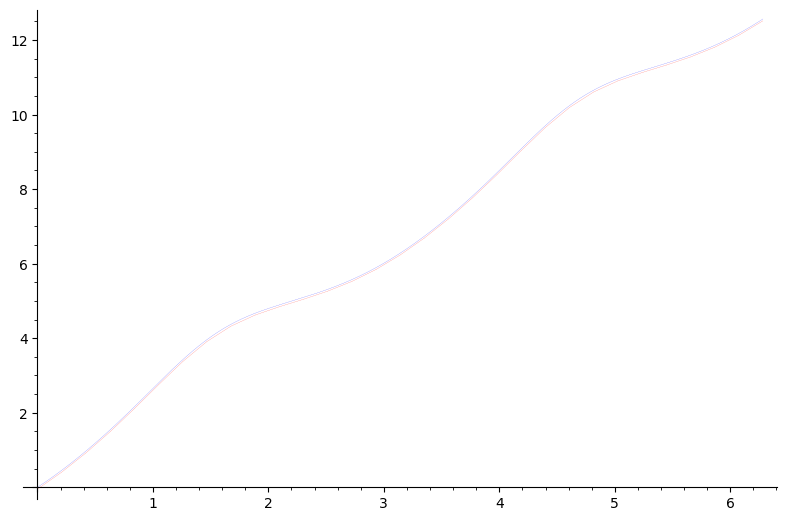

In [56]:
grafica_A_i_L(r_aprox_4, func(r), 1/20, 30)

In [57]:
var('r')
ctt_deformacio = calcula_fita_M(r_aprox_4, func(r), 1/100, 10)
print(ctt_deformacio)

1.67763199037761


Donem l'interval

In [58]:
MS2 = 2*ctt_deformacio*accuracy
MS2.n()

0.0287466029224270

In [59]:
maxim = find_local_maximum(r_aprox_4, 0, 2*pi)
minim = find_local_minimum(r_aprox_4, 0, 2*pi)

r_aprox_max = maxim[0]
r_aprox_min = minim[0]

print(r_aprox_max)

0.7048952623477494


In [60]:
I_esq = r_aprox_min-MS2
I_dret = r_aprox_max+MS2

print(I_esq.n())
print(I_dret.n())

0.472879031153783
0.733641865270176


Calculem K

In [61]:
ddf = diff(func(r), r, 2)
show(ddf.trig_reduce())

6*r*cos(2*t) + 6*r*sin(2*t) + 18*r

A mà veiem que podem calcular el màxim descomponent com
$$6 (\max(\cos(2t)+\sin(2t)+3))(\max(r))$$

In [62]:
K = 6*(3+sqrt(2))*I_dret
print(K.n())

19.4307112296018


In [63]:
(2*ctt_deformacio^2*K*accuracy).n()

0.937069767676564

Comprobem la norma infinit entre la solució i l'aproximació que acabem de trobar.

In [64]:
from sage.numerical.optimize import find_local_maximum
# sol_periodica i r_aprox_4
dif = abs(sol_periodica - r_aprox_4)
norma = find_local_maximum(dif, 0, 2*pi)
norma[0]

0.002211518838798332

Comprobem si és hiperbòlica

In [65]:
abs(numerical_integral(drfunc.subs(x = r_aprox_4), 0, 2*pi)[0])

12.566216057122626

In [66]:
(2*pi/ctt_deformacio).n()

3.74527032341899

# Plots de gràfics

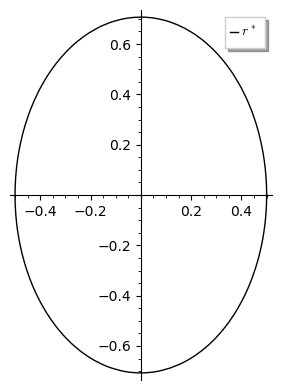

In [67]:
x_exacta = sol_periodica*cos(t)
y_exacta = sol_periodica*sin(t)
p1 = parametric_plot(
    (x_exacta,y_exacta),
    (t,0,2*pi),
    color='black',
    thickness = 1,
    legend_label = "$r^*$"
)
show(p1, aspect_ratio=1)

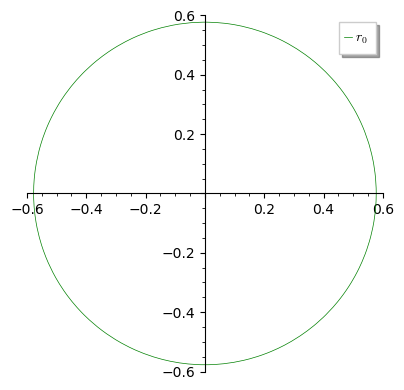

In [68]:
x_0 = r_aprox_0*cos(t)
y_0 = r_aprox_0*sin(t)
p0 = parametric_plot(
    (x_0,y_0),
    (t,0,2*pi),
    color='green',
    thickness = 0.5,
    legend_label = "$r_0$"
)
show(p0, aspect_ratio=1)

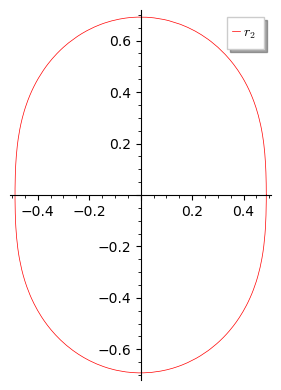

In [69]:
x_2 = r_aprox_2*cos(t)
y_2 = r_aprox_2*sin(t)
p2 = parametric_plot(
    (x_2,y_2),
    (t,0,2*pi),
    color='red',
    thickness = 0.5,
    legend_label = "$r_2$"
)
show(p2, aspect_ratio=1)

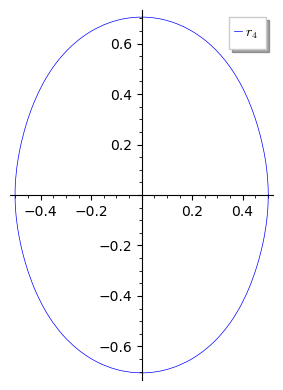

In [70]:
x_4 = r_aprox_4*cos(t)
y_4 = r_aprox_4*sin(t)
p4 = parametric_plot(
    (x_4,y_4),
    (t,0,2*pi),
    color='blue',
    thickness = 0.5,
    legend_label = "$r_4$"
)
show(p4, aspect_ratio=1)

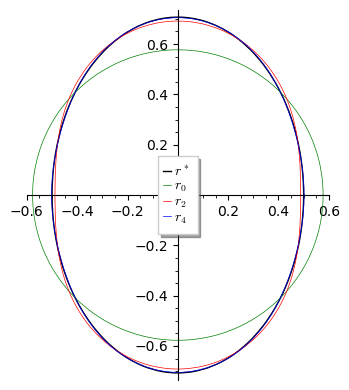

In [71]:
plot_final = p1 + p0 + p2 + p4
show(plot_final, aspect_ratio=1)#, dpi=300)

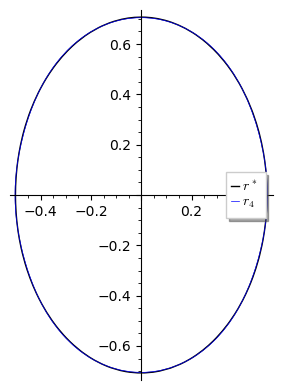

In [72]:
show(p1 + p4, aspect_ratio=1)

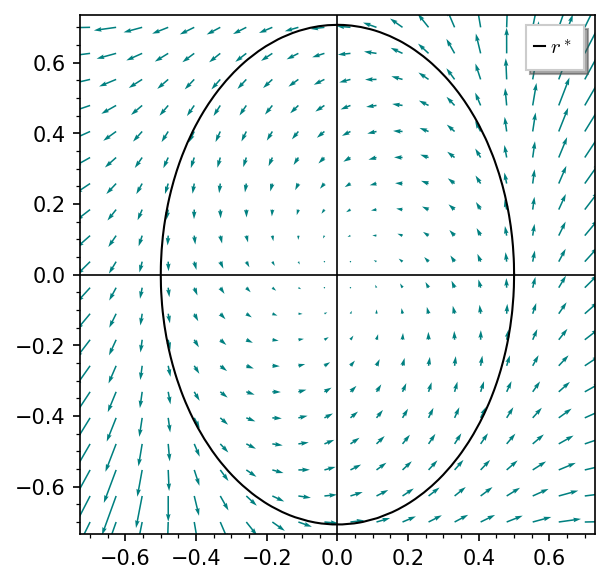

In [73]:
var('x y')
f_x = -y + x*(-1 + 4*x^2 + 2*x*y + 2*y^2)
f_y = x + y*(-1 + 4*x^2 + 2*x*y + 2*y^2)


camp = plot_vector_field([f_x, f_y], (x, -0.7, 0.7), (y, -0.7, 0.7), color='teal')

# 4. Lo mostramos con buena calidad
show(camp + p1, aspect_ratio=1, dpi=150)

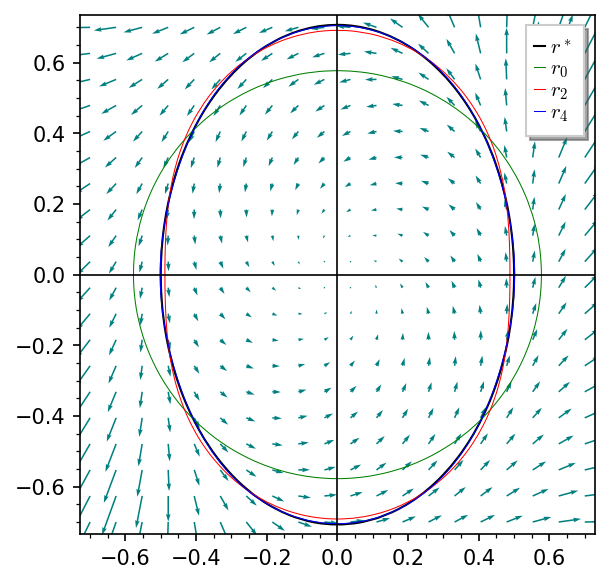

In [74]:
show(camp + p1 + p0 + p2 + p4, aspect_ratio=1, dpi=150)